# Homework 12: Results Reporting & Delivery Design
Build a stakeholder-ready written report for an investment/risk manager.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
P=Path.cwd().resolve(); P=P if P.name=='homework12' else P/'homework'/'homework12'; IMG=P/'reports/images'; IMG.mkdir(parents=True,exist_ok=True)
df=pd.read_csv(P.parent/'homework09/data/processed/aapl_features.csv',parse_dates=['date']).sort_values('date'); features=['return_lag1','rolling_mean_5','rolling_std_10','momentum_5']+[c for c in df if c.startswith('dow_')]; df['y_up']=(df.target_next_return>0).astype(int); cut=int(len(df)*.75); tr,te=df.iloc[:cut],df.iloc[cut:]
def run(weight=None):
 m=Pipeline([('scale',StandardScaler()),('logit',LogisticRegression(max_iter=1000,class_weight=weight,random_state=5040))]); m.fit(tr[features],tr.y_up); p=m.predict(te[features]); return p,{'Accuracy':accuracy_score(te.y_up,p),'Precision':precision_score(te.y_up,p,zero_division=0),'Recall':recall_score(te.y_up,p,zero_division=0)}
p0,m0=run(); p1,m1=run('balanced')

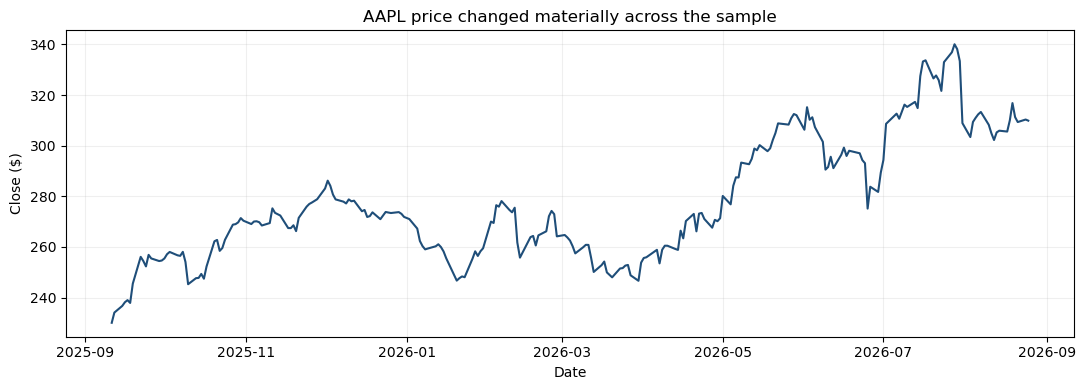

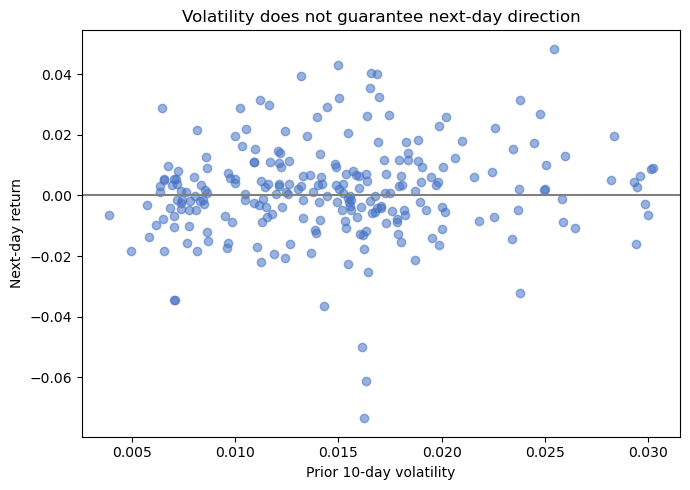

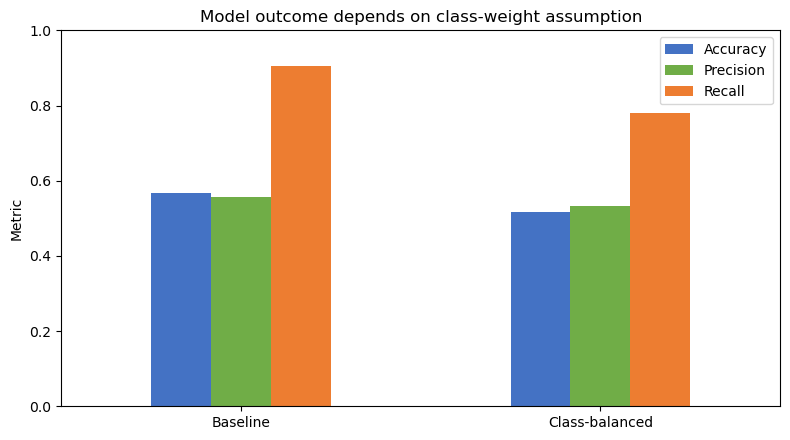

,Accuracy,Precision,Recall
Baseline,0.566667,0.557692,0.90625
Class-balanced,0.516667,0.531915,0.78125


In [2]:
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(df.date,df.close,color='#1F4E79'); ax.set(title='AAPL price changed materially across the sample',xlabel='Date',ylabel='Close ($)'); ax.grid(alpha=.2); fig.tight_layout(); fig.savefig(IMG/'aapl_price_trend.png',dpi=180); plt.show()
fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(df.rolling_std_10,df.target_next_return,alpha=.55,color='#4472C4'); ax.axhline(0,color='gray'); ax.set(title='Volatility does not guarantee next-day direction',xlabel='Prior 10-day volatility',ylabel='Next-day return'); fig.tight_layout(); fig.savefig(IMG/'volatility_vs_next_return.png',dpi=180); plt.show()
sc=pd.DataFrame({'Baseline':m0,'Class-balanced':m1}).T; fig,ax=plt.subplots(figsize=(8,4.5)); sc.plot.bar(ax=ax,color=['#4472C4','#70AD47','#ED7D31']); ax.set(title='Model outcome depends on class-weight assumption',ylabel='Metric',ylim=(0,1)); ax.tick_params(axis='x',rotation=0); fig.tight_layout(); fig.savefig(IMG/'scenario_sensitivity.png',dpi=180); plt.show(); display(sc)

In [3]:
delta=(pd.Series(m1)-pd.Series(m0)).rename('Delta: balanced - baseline'); sensitivity=pd.concat([pd.Series(m0,name='Baseline'),pd.Series(m1,name='Class-balanced'),delta],axis=1); display(sensitivity)
report=f'''# AAPL Direction Baseline: Decision Report

## Executive summary
- Do **not** deploy the model as a stand-alone trading rule; test accuracy is {m0['Accuracy']:.1%} on a short chronological holdout.
- Class weighting changes recall by {delta['Recall']:+.1%}, so operating results depend on the cost assigned to missed up-days.
- Use this transparent baseline to design longer, cost-aware backtests and monitoring—not to claim stable predictability.

## Price context
![AAPL price trend](images/aapl_price_trend.png)

The sampled price level changes through time, so results may be regime-specific. The chart describes history and does not imply continuation.

## Risk structure
![Volatility and return](images/volatility_vs_next_return.png)

Prior volatility shows broad dispersion in next-day outcomes rather than a dependable directional rule. Extreme periods are sparse.

## Sensitivity analysis
![Scenario sensitivity](images/scenario_sensitivity.png)

| Metric | Baseline | Class-balanced | Change |
|---|---:|---:|---:|
''' + ''.join(f'| {k} | {m0[k]:.3f} | {m1[k]:.3f} | {delta[k]:+.3f} |\n' for k in m0) + '''
## Assumptions & risks
The next period is assumed to resemble the single-ticker training year; all features must be available before prediction. Risks include regime change, small sample size, transaction costs, class imbalance, and data revisions. Metrics are predictive—not causal—and do not quantify portfolio loss.

## What this means for you
Treat any signal as experimental. Require a longer walk-forward test, transaction-cost and drawdown analysis, uncertainty intervals, and volatility-regime monitoring before capital allocation. Choose class weighting only after specifying whether false positives or missed up-days are more costly.
'''
(P/'reports/final_report.md').write_text(report); print('Saved reports/final_report.md and three figures.')

,Baseline,Class-balanced,Delta: balanced - baseline
Accuracy,0.566667,0.516667,-0.050000
Precision,0.557692,0.531915,-0.025777
Recall,0.906250,0.781250,-0.125000


Saved reports/final_report.md and three figures.


The final report is intentionally concise and decision-oriented. Each chart has a single message, uses consistent colors and labels, and sits beside its limitations; the sensitivity table quantifies how an alternate assumption changes outcomes.